### Why Do We Need Logistic Regression?
- If Linear Regression predicts any value from −∞ to +∞, how can we use it for classification (0 or 1)?
- Linear Regression, the output might be continuous data
- These values do not represent **probabilities**.
- So we need a function that converts any number into a probability between 0 and 1.
- That function is called the **Sigmoid Function.**

### The Core Idea of Logistic Regression

Logistic regression converts a linear equation into probability using the Sigmoid Function.

Linear equation:

- **`z=β0​+β1​x1​+β2​x2​+...+βn​xn`**



Then apply sigmoid:

P(y=1)=
1+e
−z
1
| z  | Probability |
| -- | ----------- |
| -4 | 0.018       |
| 0  | 0.5         |
| 4  | 0.982       |


#### Logistic regression produces an S-shaped curve.

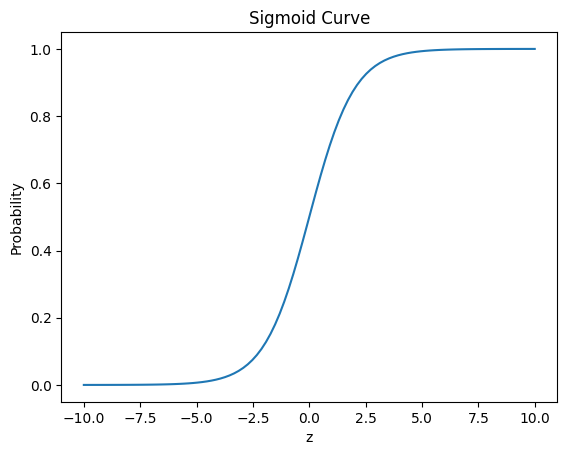

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,100)
y = 1/(1+np.exp(-x))

plt.plot(x,y)
plt.title("Sigmoid Curve")
plt.xlabel("z")
plt.ylabel("Probability")
plt.show()

#### `Extreme negative → probability near 0`
#### `Extreme positive → probability near 1`

**About Dataset**
- The Breast Cancer Wisconsin Dataset is a well-known machine learning dataset used for binary classification of breast tumors as malignant or benign. It contains features computed from digitized images of fine needle aspirate (FNA) samples of breast tissue, making it a benchmark for testing classification algorithms in medical diagnostics.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [32]:
data = load_breast_cancer()

X = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [33]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [35]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [36]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)

In [38]:
y_pred

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

In [39]:
y_prob

array([[1.21204089e-01, 8.78795911e-01],
       [9.99999970e-01, 3.04889112e-08],
       [9.98408527e-01, 1.59147275e-03],
       [1.21637831e-03, 9.98783622e-01],
       [1.40281212e-04, 9.99859719e-01],
       [1.00000000e+00, 1.96512748e-10],
       [1.00000000e+00, 6.15924465e-11],
       [9.80725315e-01, 1.92746849e-02],
       [1.58008552e-02, 9.84199145e-01],
       [5.64266919e-03, 9.94357331e-01],
       [7.06135235e-02, 9.29386477e-01],
       [9.99194698e-01, 8.05302054e-04],
       [1.10557843e-02, 9.88944216e-01],
       [8.24914422e-01, 1.75085578e-01],
       [7.81540044e-04, 9.99218460e-01],
       [9.98267356e-01, 1.73264409e-03],
       [1.18490683e-03, 9.98815093e-01],
       [1.18342780e-05, 9.99988166e-01],
       [5.90354044e-07, 9.99999410e-01],
       [9.99999284e-01, 7.15588300e-07],
       [1.72029746e-01, 8.27970254e-01],
       [7.67098553e-03, 9.92329014e-01],
       [9.99999994e-01, 6.13233119e-09],
       [3.32138909e-04, 9.99667861e-01],
       [3.437609

In [40]:
print("Accuracy:",accuracy_score(y_test,y_pred))

print(confusion_matrix(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.956140350877193
[[39  4]
 [ 1 70]]
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [41]:

model.intercept_

array([29.49750844])

In [42]:
model.coef_

array([[ 0.98815512,  0.22640228, -0.36995431,  0.02635943, -0.15322228,
        -0.23234042, -0.5203548 , -0.27449328, -0.22352681, -0.0365289 ,
        -0.09341242,  1.39239584, -0.16356872, -0.08919259, -0.02172425,
         0.04401998, -0.04531674, -0.03141112, -0.03452133,  0.01111313,
         0.10033171, -0.51526056, -0.01637195, -0.01662803, -0.301903  ,
        -0.76436893, -1.4099331 , -0.49684213, -0.73404747, -0.10080837]])

### Limitations of Logistic Regression

- Works best for linear decision boundaries
- Struggles with complex nonlinear patterns
- Sensitive to multicollinearity
- Needs feature scaling

### Workflow

1. Understand classification problem
2. Convert linear output into probability using sigmoid
3. Use log loss as cost function
4. Optimize parameters using gradient descent
5. Predict probabilities
6. Apply threshold for classification

### 1. Why Linear Regression Fails for Classification
- Linear regression predicts values beyond 0 and 1, while classification needs probabilities.

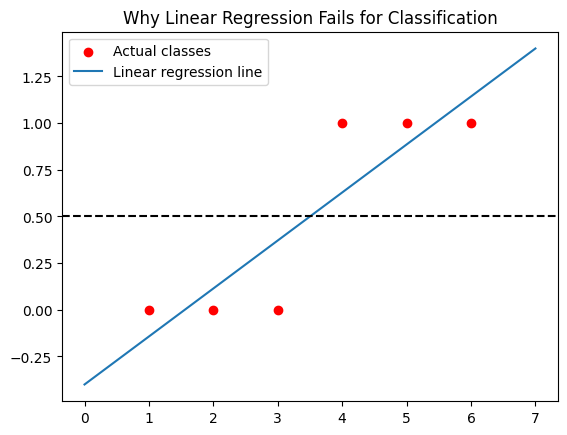

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# fake classification data
X = np.array([[1],[2],[3],[4],[5],[6]])
y = np.array([0,0,0,1,1,1])

model = LinearRegression()
model.fit(X,y)

x_test = np.linspace(0,7,100).reshape(-1,1)
y_pred = model.predict(x_test)

plt.scatter(X,y,color="red",label="Actual classes")
plt.plot(x_test,y_pred,label="Linear regression line")
plt.axhline(0.5,linestyle="--",color="black")
plt.legend()
plt.title("Why Linear Regression Fails for Classification")
plt.show()

See? Linear regression predicts values like 1.3 or -0.2, which makes no sense for probabilities.

### 2. Sigmoid Converts Numbers to Probabilities
| Input | Probability |
| ----- | ----------- |
| -5    | ~0          |
| 0     | 0.5         |
| 5     | ~1          |


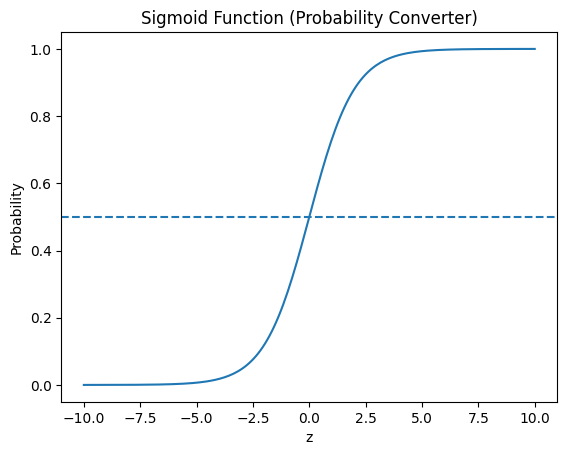

In [27]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10,10,200)
sigmoid = 1/(1+np.exp(-x))

plt.plot(x,sigmoid)
plt.axhline(0.5,linestyle="--")
plt.title("Sigmoid Function (Probability Converter)")
plt.xlabel("z")
plt.ylabel("Probability")
plt.show()

#### NOte : Logistic regression doesn't predict class directly — it predicts probability first.

### 3. Decision Boundary

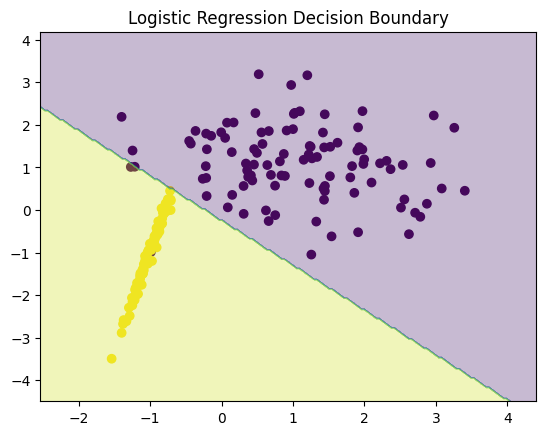

In [28]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

X,y = make_classification(n_samples=200,n_features=2,
                          n_redundant=0,n_clusters_per_class=1)

model = LogisticRegression()
model.fit(X,y)

plt.scatter(X[:,0],X[:,1],c=y)

x_min,x_max = X[:,0].min()-1,X[:,0].max()+1
y_min,y_max = X[:,1].min()-1,X[:,1].max()+1

xx,yy = np.meshgrid(np.linspace(x_min,x_max,200),
                    np.linspace(y_min,y_max,200))

Z = model.predict(np.c_[xx.ravel(),yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx,yy,Z,alpha=0.3)
plt.title("Logistic Regression Decision Boundary")
plt.show()